# Human annotation — per-dimension selection

Loads the four independent files from `build_dataset.py` (default: `outputs/winners/`).

Purpose: **validate LLM judges** per dimension. Each dimension has its own sample of pairs.

The section at the bottom **simulates** human annotations (random `left` / `right` / `tie`) and plots human vs LLM panel majority confusion matrices — a dry run of the post-annotation agreement analysis.

In [65]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
HA_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "build_dataset.py").is_file() else NOTEBOOK_DIR / "human_annotation"
DATASET_NAME = "winners"
OUT_DIR = HA_DIR / "outputs" / DATASET_NAME
META_PATH = OUT_DIR / "selection_metadata.json"

LABELS = ["left", "right", "tie"]
ANNOTATOR_COLS = ["human_choice__annotator_1", "human_choice__annotator_2"]
MIMIC_SEEDS = [42, 137]  # reproducible fake human labels (one seed per annotator)

meta = json.loads(META_PATH.read_text(encoding="utf-8"))
dims = meta["dimensions"]
frames = {d: pd.read_csv(OUT_DIR / f"{d}.csv") for d in dims}

JUDGE_COLS = [c for c in frames[dims[0]].columns if c.startswith("llm_vote__")]
JUDGE_LABELS = [c.removeprefix("llm_vote__").replace("_", "-") for c in JUDGE_COLS]
BUCKET_ORDER = [
    "low_agreement",
    "tie_majority",
    "high_agreement",
    "reference_challenged",
    "representative",
]
LLM_SUMMARY_COLS = ["llm_majority", "llm_votes_left", "llm_votes_right", "llm_votes_tie", "llm_vote_entropy"]

print(f"Per dimension: {meta['per_dimension_selected']}")
print(f"Total rows: {meta['total_rows_exported']}")
print(f"Annotators: {len(ANNOTATOR_COLS)}, LLM judges: {len(JUDGE_COLS)}")

Per dimension: {'relevance': 25, 'consistency': 25, 'newsworthiness': 25, 'hygiene': 25}
Total rows: 100
Annotators: 2, LLM judges: 4


## Summary per dimension

In [66]:
rows = []
for dim, df in frames.items():
    rows.append({
        "dimension": dim,
        "rows": len(df),
        "unique_docs": df["doc_id"].nunique(),
        "mean_entropy": round(df["llm_vote_entropy"].mean(), 3),
    })
display(pd.DataFrame(rows))

bucket_tbl = pd.DataFrame([
    {"dimension": d, **meta["by_dimension"][d]["counts_by_bucket"]}
    for d in dims
]).set_index("dimension")
display(bucket_tbl.fillna(0).astype(int))

,dimension,rows,unique_docs,mean_entropy
0,relevance,25,15,0.665
1,consistency,25,12,0.672
2,newsworthiness,25,16,0.672
3,hygiene,25,15,0.890


,high_agreement,low_agreement,representative,reference_challenged
dimension,,,,
relevance,6,10,4,5
consistency,6,10,4,5
newsworthiness,6,10,4,5
hygiene,6,10,4,5


## Mimic human annotation

Simulate **two annotators** with independent random choices (`left` / `right` / `tie`).

After real annotation, replace with columns `human_choice__annotator_1` and `human_choice__annotator_2` in each CSV (or load separate filled files).

In [67]:
annotated = {}

for dim, df in frames.items():
    out = df.copy()
    for col, seed in zip(ANNOTATOR_COLS, MIMIC_SEEDS):
        rng = np.random.default_rng(seed + sum(ord(c) for c in dim))
        out[col] = rng.choice(LABELS, size=len(out))
    out["human_choice"] = out[ANNOTATOR_COLS[0]]  # alias for cells below
    annotated[dim] = out

def confusion_matrix(human: pd.Series, llm: pd.Series, labels: list[str]) -> np.ndarray:
    idx = {lbl: i for i, lbl in enumerate(labels)}
    mat = np.zeros((len(labels), len(labels)), dtype=int)
    for h, l in zip(human, llm):
        h, l = str(h).strip().lower(), str(l).strip().lower()
        if h in idx and l in idx:
            mat[idx[h], idx[l]] += 1
    return mat


def plot_confusion_heatmap(
    ax,
    mat: np.ndarray,
    title: str,
    *,
    xlabel: str = "LLM majority",
    ylabel: str = "Human (simulated)",
) -> None:
    im = ax.imshow(mat, cmap="Blues", vmin=0)
    ax.set_xticks(range(len(LABELS)))
    ax.set_yticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS)
    ax.set_yticklabels(LABELS)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = int(mat[i, j])
            color = "white" if val > mat.max() / 2 else "black"
            ax.text(j, i, str(val), ha="center", va="center", color=color, fontsize=11)
    return im


def agreement_pct(human: pd.Series, llm: pd.Series) -> float:
    h = human.astype(str).str.strip().str.lower()
    l = llm.astype(str).str.strip().str.lower()
    mask = h.isin(LABELS) & l.isin(LABELS)
    if not mask.any():
        return float("nan")
    return (h[mask] == l[mask]).mean()


preview_cols = ["item_id", *ANNOTATOR_COLS, "llm_majority", *JUDGE_COLS]
annotated["relevance"][preview_cols].head()

,item_id,human_choice__annotator_1,human_choice__annotator_2,llm_majority,llm_vote__gpt_5_mini,llm_vote__google_gemini_2_5_flash_preview_05_20,llm_vote__anthropic_claude_3_5_haiku_20241022,llm_vote__mistral_medium_latest
0,human_ann_relevance_0001,right,tie,left,left,left,left,left
1,human_ann_relevance_0002,tie,tie,left,left,left,left,left
2,human_ann_relevance_0003,tie,left,left,left,left,left,left
3,human_ann_relevance_0004,tie,left,right,right,right,right,right
4,human_ann_relevance_0005,left,right,right,right,right,right,right


## Human vs LLM panel majority — confusion heatmaps

Rows = simulated human label, columns = `llm_majority` (4-judge plurality on that dimension).

With random human labels, expect ~33% accuracy and a roughly uniform matrix.

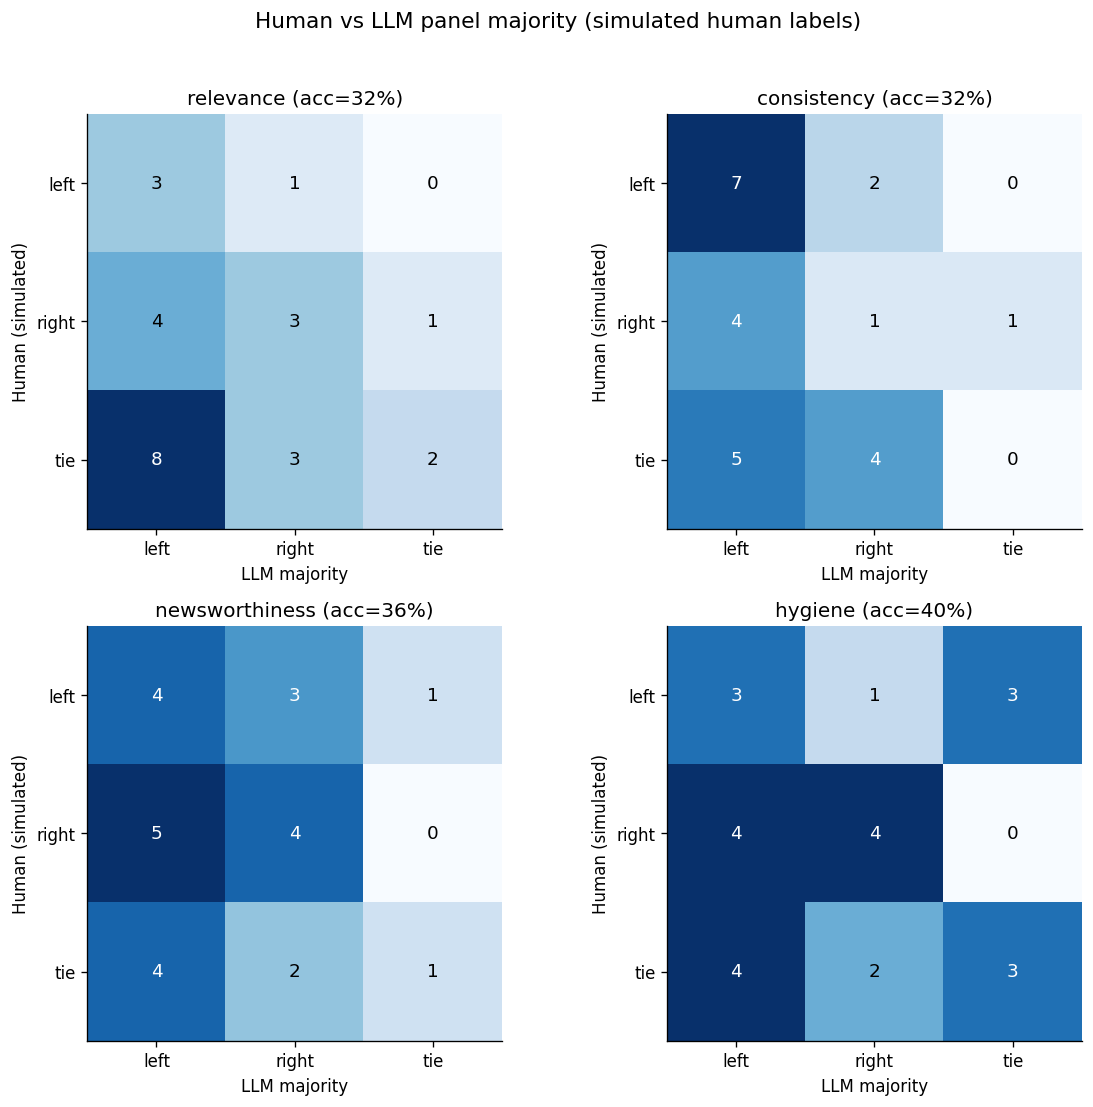

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

for ax, dim in zip(axes, dims):
    df = annotated[dim]
    human = df["human_choice"]
    llm = df["llm_majority"]
    mat = confusion_matrix(human, llm, LABELS)
    acc = (human.str.lower().values == llm.str.lower().values).mean()
    plot_confusion_heatmap(ax, mat, f"{dim} (acc={acc:.0%})")

plt.suptitle("Human vs LLM panel majority (simulated human labels)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## Human vs LLM — agreement % (2×4 heatmap)

Rows = two human annotators. Columns = four LLM judges. Cell value = % agreement (pooled over all dimension files).

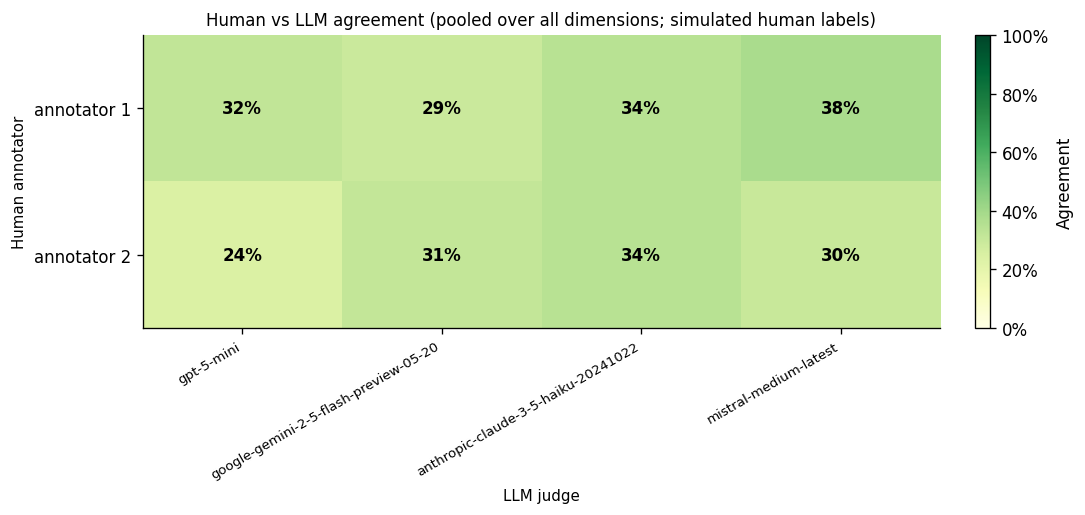

In [69]:
def human_llm_agreement_matrix(
    annotated: dict[str, pd.DataFrame],
    annotator_cols: list[str],
    judge_cols: list[str],
) -> np.ndarray:
    """Shape: (n_annotators, n_judges). Pooled over all dimensions."""
    combined = pd.concat(annotated.values(), ignore_index=True)
    mat = np.full((len(annotator_cols), len(judge_cols)), np.nan)
    for i, human_col in enumerate(annotator_cols):
        human = combined[human_col]
        for j, judge_col in enumerate(judge_cols):
            mat[i, j] = agreement_pct(human, combined[judge_col])
    return mat


def human_llm_agreement_matrix_for_dim(
    df: pd.DataFrame,
    annotator_cols: list[str],
    judge_cols: list[str],
) -> np.ndarray:
    """Shape: (n_annotators, n_judges) for one dimension file."""
    mat = np.full((len(annotator_cols), len(judge_cols)), np.nan)
    for i, human_col in enumerate(annotator_cols):
        for j, judge_col in enumerate(judge_cols):
            mat[i, j] = agreement_pct(df[human_col], df[judge_col])
    return mat


def draw_agreement_heatmap(
    ax,
    mat: np.ndarray,
    annotator_labels: list[str],
    judge_labels: list[str],
    *,
    title: str | None = None,
    show_ylabel: bool = True,
    show_xlabel: bool = True,
) -> None:
    ax.imshow(mat, vmin=0, vmax=1, cmap="YlGn", aspect="auto")
    ax.set_xticks(range(len(judge_labels)))
    ax.set_xticklabels(judge_labels, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(annotator_labels)))
    ax.set_yticklabels(annotator_labels if show_ylabel else [])
    if show_xlabel:
        ax.set_xlabel("LLM judge", fontsize=9)
    if show_ylabel:
        ax.set_ylabel("Human annotator", fontsize=9)
    if title:
        ax.set_title(title, fontsize=10)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            label = "n/a" if np.isnan(val) else f"{val:.0%}"
            color = "white" if (not np.isnan(val) and val > 0.55) else "black"
            ax.text(j, i, label, ha="center", va="center", color=color, fontsize=10, fontweight="600")


def plot_human_llm_agreement_heatmap(
    mat: np.ndarray,
    annotator_labels: list[str],
    judge_labels: list[str],
    title: str,
) -> None:
    fig, ax = plt.subplots(figsize=(1.8 * len(judge_labels) + 2, 1.2 * len(annotator_labels) + 2))
    draw_agreement_heatmap(ax, mat, annotator_labels, judge_labels, title=title)
    cbar = fig.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Agreement")
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.tight_layout()
    plt.show()


annotator_labels = [c.removeprefix("human_choice__").replace("_", " ") for c in ANNOTATOR_COLS]
acc_mat = human_llm_agreement_matrix(annotated, ANNOTATOR_COLS, JUDGE_COLS)
plot_human_llm_agreement_heatmap(
    acc_mat,
    annotator_labels,
    JUDGE_LABELS,
    "Human vs LLM agreement (pooled over all dimensions; simulated human labels)",
)

## Human vs LLM — agreement % per dimension (2×4 each)

Same 2 annotators × 4 LLM judges layout, but computed **within each dimension file** (25 items each).


C:\Users\fatemi\AppData\Local\Temp\2\ipykernel_12444\3571381974.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


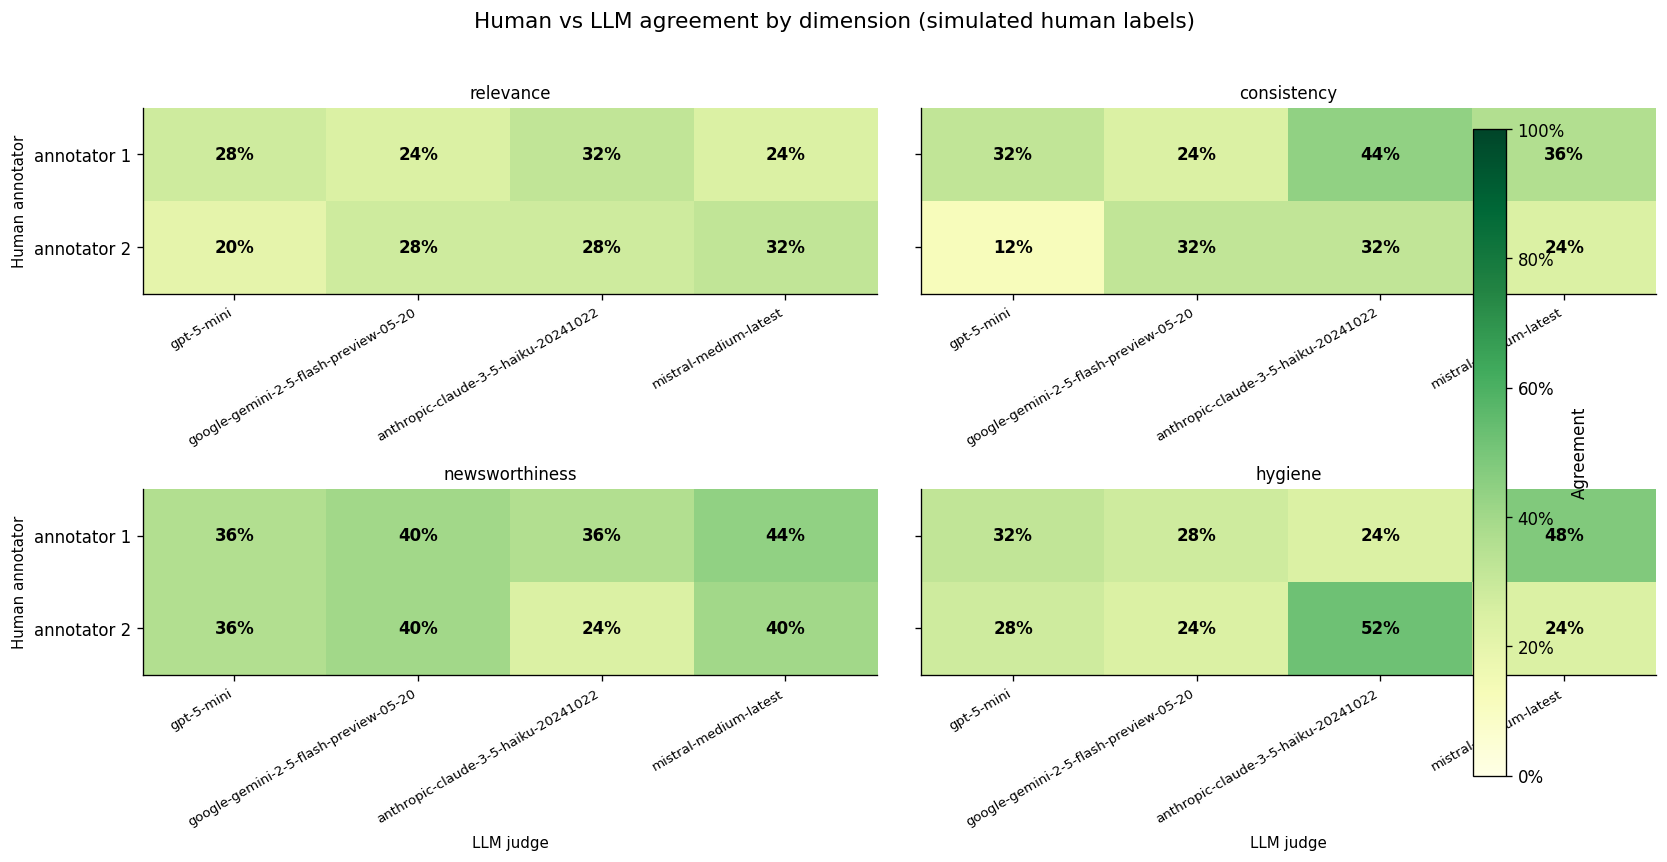

In [70]:
annotator_labels = [c.removeprefix("human_choice__").replace("_", " ") for c in ANNOTATOR_COLS]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.ravel()

for idx, (ax, dim) in enumerate(zip(axes, dims)):
    mat = human_llm_agreement_matrix_for_dim(annotated[dim], ANNOTATOR_COLS, JUDGE_COLS)
    draw_agreement_heatmap(
        ax,
        mat,
        annotator_labels,
        JUDGE_LABELS,
        title=dim,
        show_ylabel=(idx in (0, 2)),
        show_xlabel=(idx in (2, 3)),
    )

fig.suptitle("Human vs LLM agreement by dimension (simulated human labels)", y=1.02, fontsize=13)
cbar = fig.colorbar(axes[0].images[0], ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Agreement")
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()


## Inter-annotator agreement

How much do the two human annotators agree with each other? Simple agreement % plus 3×3 confusion matrices (rows = annotator 1, columns = annotator 2).


,scope,n,agreement_pct
0,relevance,25,24%
1,consistency,25,32%
2,newsworthiness,25,36%
3,hygiene,25,20%
4,pooled,100,28%


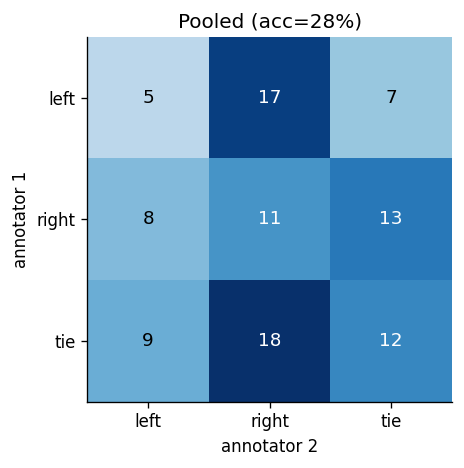

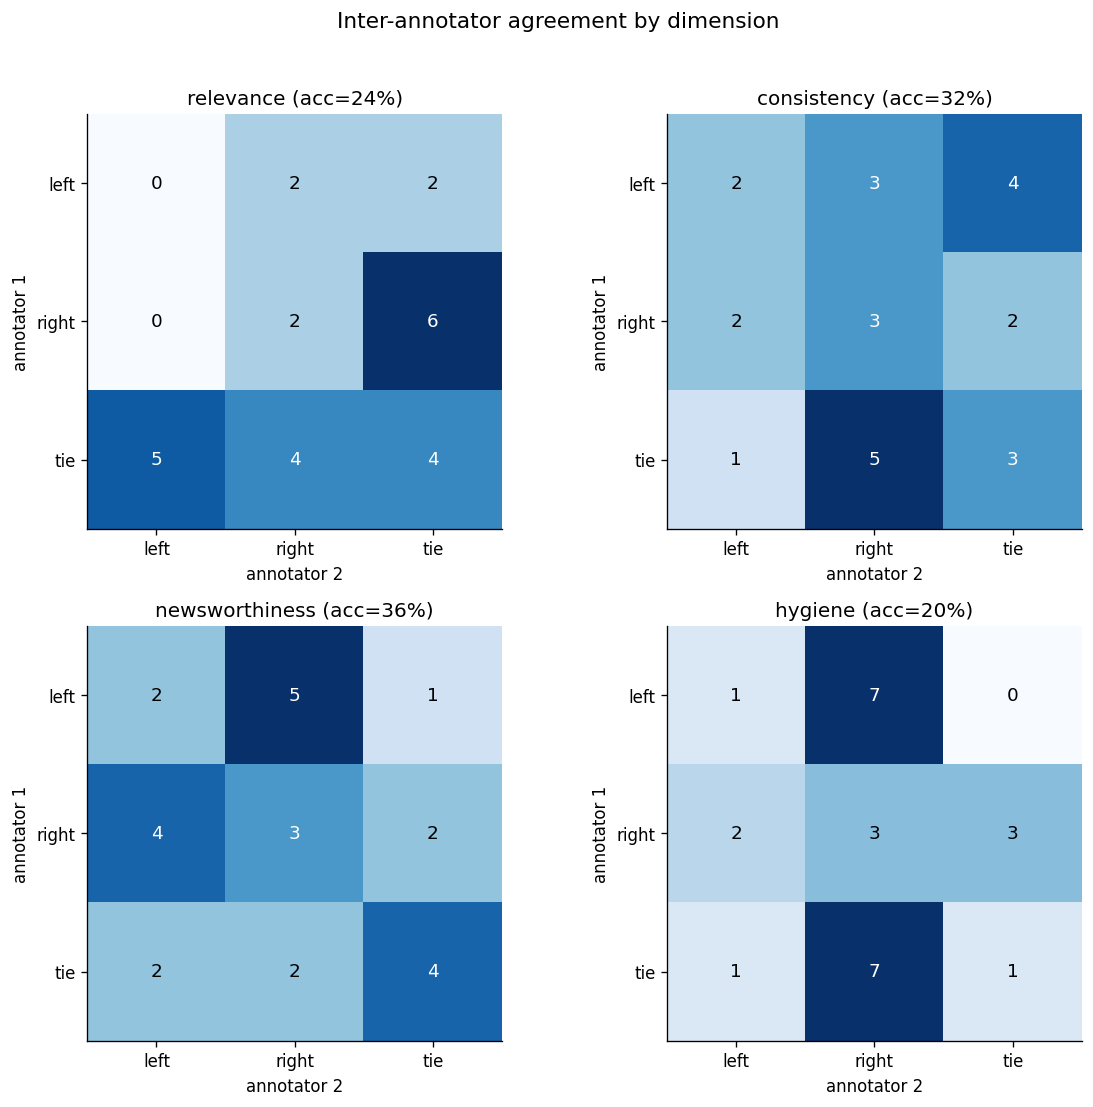

In [71]:
def inter_annotator_agreement(df: pd.DataFrame) -> float:
    return agreement_pct(df[ANNOTATOR_COLS[0]], df[ANNOTATOR_COLS[1]])


combined = pd.concat(annotated.values(), ignore_index=True)
a1, a2 = ANNOTATOR_COLS
a1_label = a1.removeprefix("human_choice__").replace("_", " ")
a2_label = a2.removeprefix("human_choice__").replace("_", " ")

inter_rows = []
for dim, df in annotated.items():
    inter_rows.append({"scope": dim, "n": len(df), "agreement": inter_annotator_agreement(df)})
inter_rows.append({"scope": "pooled", "n": len(combined), "agreement": inter_annotator_agreement(combined)})

inter_summary = pd.DataFrame(inter_rows)
inter_summary["agreement_pct"] = inter_summary["agreement"].map(lambda x: f"{x:.0%}")
display(inter_summary[["scope", "n", "agreement_pct"]])

mat_pooled = confusion_matrix(combined[a1], combined[a2], LABELS)
acc_pooled = inter_annotator_agreement(combined)

fig, ax = plt.subplots(figsize=(4.5, 4))
plot_confusion_heatmap(
    ax,
    mat_pooled,
    f"Pooled (acc={acc_pooled:.0%})",
    xlabel=a2_label,
    ylabel=a1_label,
)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

for ax, dim in zip(axes, dims):
    df = annotated[dim]
    mat = confusion_matrix(df[a1], df[a2], LABELS)
    acc = inter_annotator_agreement(df)
    plot_confusion_heatmap(
        ax,
        mat,
        f"{dim} (acc={acc:.0%})",
        xlabel=a2_label,
        ylabel=a1_label,
    )

plt.suptitle("Inter-annotator agreement by dimension", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## Agreement by selection bucket

Same metrics as above, broken down by stratification bucket (pooled over all dimensions). Useful to see whether human–LLM alignment differs on hard vs easy vs reference-challenged cases.


Inter-annotator agreement by bucket


,bucket,n,agreement_pct
0,low_agreement,40,30%
1,high_agreement,24,25%
2,reference_challenged,20,35%
3,representative,16,19%


Human vs LLM agreement by bucket (rows = annotator)


n llm_majority gpt_5_mini  \
bucket               annotator                                 
low_agreement        annotator 1  40          40%        35%   
                     annotator 2  40          38%        20%   
high_agreement       annotator 1  24          29%        29%   
                     annotator 2  24          33%        33%   
reference_challenged annotator 1  20          32%        30%   
                     annotator 2  20          11%        10%   
representative       annotator 1  16          43%        31%   
                     annotator 2  16          36%        38%   

                                 google_gemini_2_5_flash_preview_05_20  \
bucket               annotator                                           
low_agreement        annotator 1                                   22%   
                     annotator 2                                   40%   
high_agreement       annotator 1                                   29%   
                     annotator 2                                   33%   
reference_challenged annotator 1                                   25%   
                     annotator 2                                   10%   
representative       annotator 1                                   50%   
                     annotator 2                                   31%   

                                 anthropic_claude_3_5_haiku_20241022  \
bucket               annotator                                         
low_agreement        annotator 1                                 40%   
                     annotator 2                                 42%   
high_agreement       annotator 1                                 29%   
                     annotator 2                                 33%   
reference_challenged annotator 1                                 25%   
                     annotator 2                                 20%   
representative       annotator 1                                 38%   
                     annotator 2                                 31%   

                                 mistral_medium_latest  
bucket               annotator                          
low_agreement        annotator 1                   42%  
                     annotator 2                   35%  
high_agreement       annotator 1                   29%  
                     annotator 2                   33%  
reference_challenged annotator 1                   35%  
                     annotator 2                   10%  
representative       annotator 1                   44%  
                     annotator 2                   38%

C:\Users\fatemi\AppData\Local\Temp\2\ipykernel_12444\101253927.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


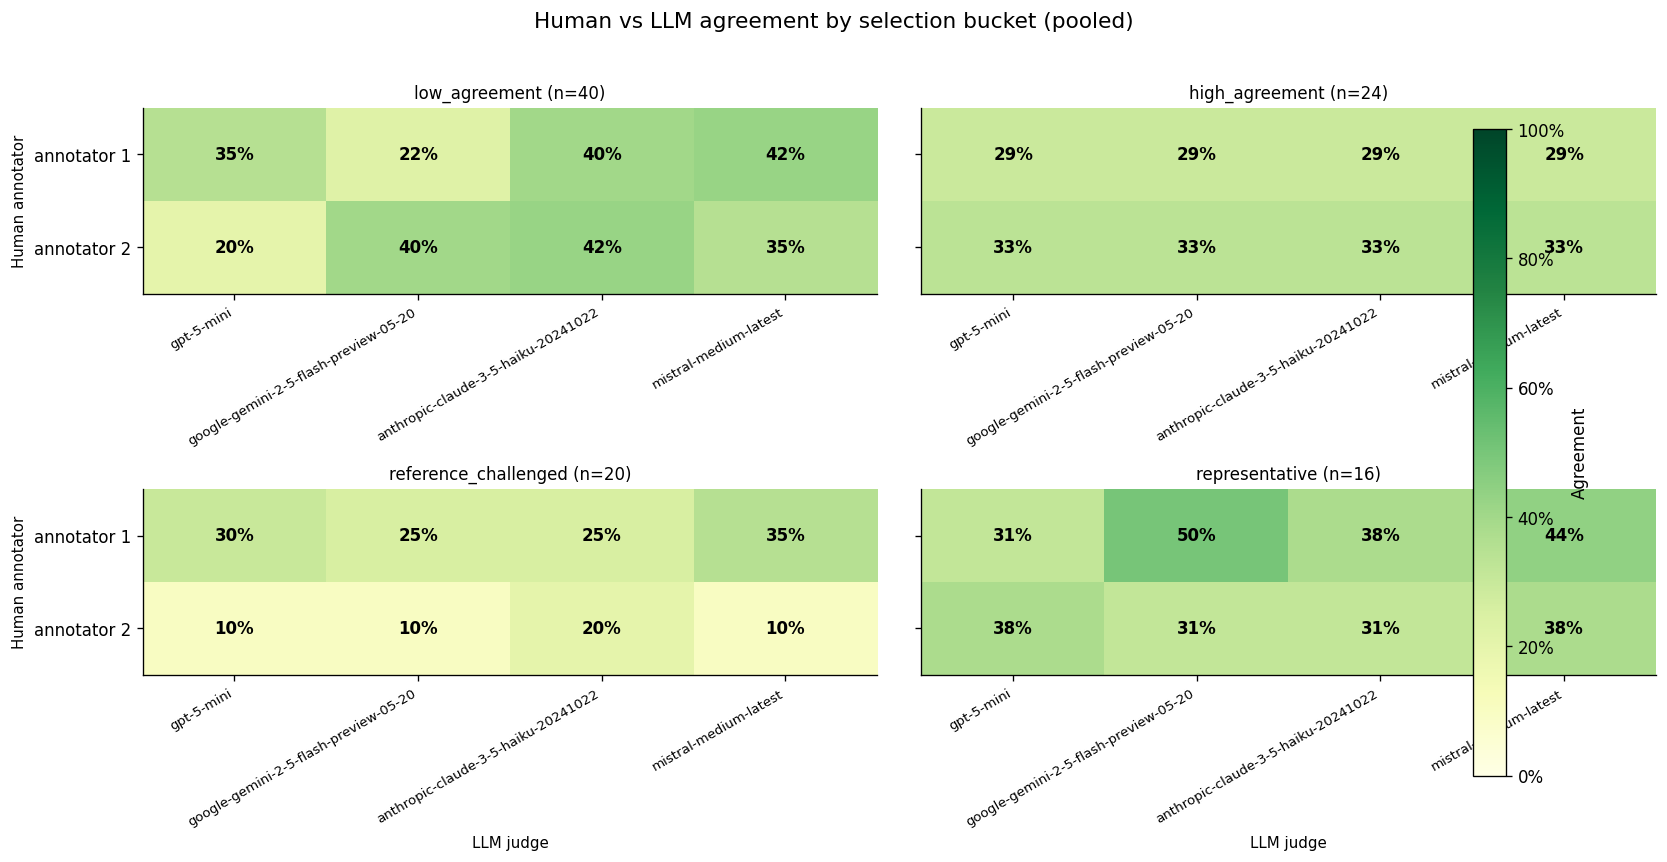

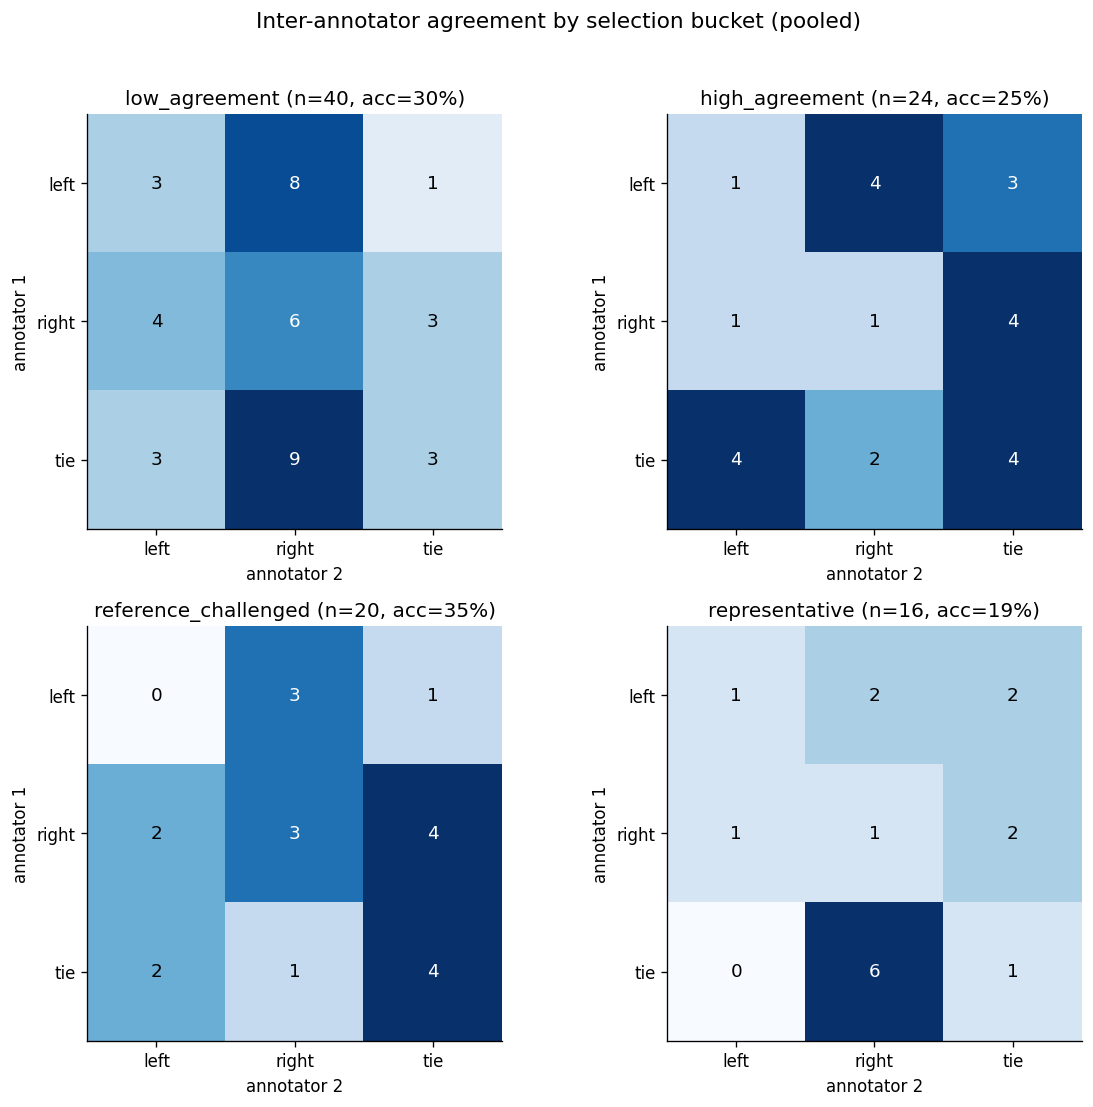

In [72]:
combined = pd.concat(annotated.values(), ignore_index=True)
annotator_labels = [c.removeprefix("human_choice__").replace("_", " ") for c in ANNOTATOR_COLS]
a1, a2 = ANNOTATOR_COLS
a1_label = a1.removeprefix("human_choice__").replace("_", " ")
a2_label = a2.removeprefix("human_choice__").replace("_", " ")

inter_by_bucket = []
human_llm_by_bucket = []
for bucket in BUCKET_ORDER:
    sub = combined[combined["selection_bucket"] == bucket]
    if sub.empty:
        continue
    inter_by_bucket.append(
        {
            "bucket": bucket,
            "n": len(sub),
            "inter_annotator_agreement": inter_annotator_agreement(sub),
        }
    )
    for human_col in ANNOTATOR_COLS:
        a_name = human_col.removeprefix("human_choice__").replace("_", " ")
        row = {
            "bucket": bucket,
            "annotator": a_name,
            "n": len(sub),
            "llm_majority": agreement_pct(sub[human_col], sub["llm_majority"]),
        }
        for judge_col in JUDGE_COLS:
            row[judge_col.removeprefix("llm_vote__")] = agreement_pct(sub[human_col], sub[judge_col])
        human_llm_by_bucket.append(row)

print("Inter-annotator agreement by bucket")
inter_tbl = pd.DataFrame(inter_by_bucket)
inter_tbl["agreement_pct"] = inter_tbl["inter_annotator_agreement"].map(lambda x: f"{x:.0%}")
display(inter_tbl[["bucket", "n", "agreement_pct"]])

print("Human vs LLM agreement by bucket (rows = annotator)")
human_llm_tbl = pd.DataFrame(human_llm_by_bucket)
pct_cols = ["llm_majority", *[c.removeprefix("llm_vote__") for c in JUDGE_COLS]]
display(
    human_llm_tbl.assign(
        **{c: human_llm_tbl[c].map(lambda x: f"{x:.0%}") for c in pct_cols}
    )[["bucket", "annotator", "n", *[f"{c}" for c in pct_cols]]]
    .set_index(["bucket", "annotator"])
)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.ravel()
for idx, (ax, bucket) in enumerate(zip(axes, BUCKET_ORDER)):
    sub = combined[combined["selection_bucket"] == bucket]
    mat = human_llm_agreement_matrix_for_dim(sub, ANNOTATOR_COLS, JUDGE_COLS)
    draw_agreement_heatmap(
        ax,
        mat,
        annotator_labels,
        JUDGE_LABELS,
        title=f"{bucket} (n={len(sub)})",
        show_ylabel=(idx in (0, 2)),
        show_xlabel=(idx in (2, 3)),
    )

fig.suptitle("Human vs LLM agreement by selection bucket (pooled)", y=1.02, fontsize=13)
cbar = fig.colorbar(axes[0].images[0], ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Agreement")
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
for ax in axes[len(BUCKET_ORDER):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()
for ax, bucket in zip(axes, BUCKET_ORDER):
    sub = combined[combined["selection_bucket"] == bucket]
    if sub.empty:
        ax.axis("off")
        continue
    mat = confusion_matrix(sub[a1], sub[a2], LABELS)
    acc = inter_annotator_agreement(sub)
    plot_confusion_heatmap(
        ax,
        mat,
        f"{bucket} (n={len(sub)}, acc={acc:.0%})",
        xlabel=a2_label,
        ylabel=a1_label,
    )

plt.suptitle("Inter-annotator agreement by selection bucket (pooled)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## Optional: human vs each LLM judge (one dimension)

Same analysis broken down by individual judge — useful for the paper's per-judge tables.

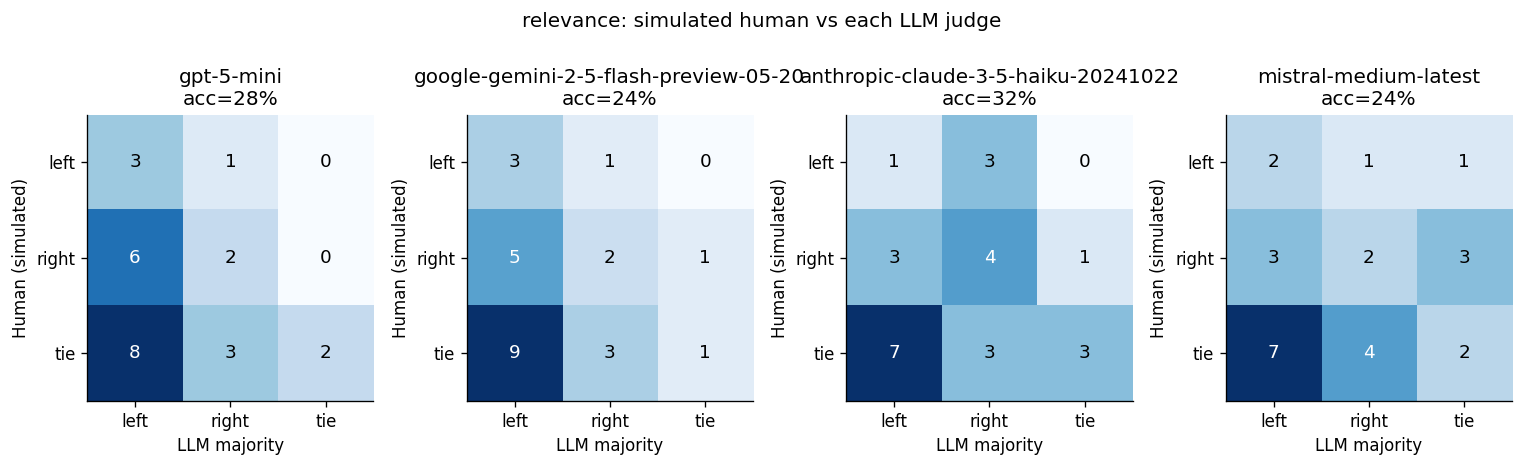

In [ ]:
SHOW_DIM = "relevance"  # change to inspect another dimension
df = annotated[SHOW_DIM]
human = df["human_choice"]

fig, axes = plt.subplots(1, len(JUDGE_COLS), figsize=(3.2 * len(JUDGE_COLS), 3.5))
if len(JUDGE_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, JUDGE_COLS):
    judge_name = col.removeprefix("llm_vote__").replace("_", "-")
    llm = df[col]
    mat = confusion_matrix(human, llm, LABELS)
    acc = (human.str.lower().values == llm.str.lower().values).mean()
    plot_confusion_heatmap(ax, mat, f"{judge_name}\nacc={acc:.0%}")

plt.suptitle(f"{SHOW_DIM}: simulated human vs each LLM judge", y=1.05)
plt.tight_layout()
plt.show()

In [139]:
dim = "relevance"

path_rel = f"""outputs/winners/{dim}.csv"""
rel = pd.read_csv(path_rel)


dim = "hygiene"

path_rel = f"""outputs/winners/{dim}.csv"""
hyg = pd.read_csv(path_rel)


dim = "newsworthiness"

path_rel = f"""outputs/winners/{dim}.csv"""
new = pd.read_csv(path_rel)


dim = "consistency"

path_rel = f"""outputs/winners/{dim}.csv"""
con = pd.read_csv(path_rel)

In [140]:
rel.columns

Index(['item_id', 'doc_id', 'dimension', 'dimension_color', 'pair_key',
       'selection_bucket', 'left_model', 'right_model', 'summary_left',
       'summary_right', 'source_text', 'reference_summary',
       'annotation_prompt', 'human_choice', 'llm_majority', 'llm_votes_left',
       'llm_votes_right', 'llm_votes_tie', 'llm_vote_entropy',
       'llm_vote__gpt_5_mini',
       'llm_vote__google_gemini_2_5_flash_preview_05_20',
       'llm_vote__anthropic_claude_3_5_haiku_20241022',
       'llm_vote__mistral_medium_latest'],
      dtype='str')

In [141]:
rel.selection_bucket.value_counts()

selection_bucket
low_agreement           10
reference_challenged     5
high_agreement           4
representative           4
tie_majority             2
Name: count, dtype: int64

In [148]:
rel[rel["selection_bucket"]=="high_agreement"]

,item_id,doc_id,dimension,dimension_color,pair_key,selection_bucket,left_model,right_model,summary_left,summary_right,...,human_choice,llm_majority,llm_votes_left,llm_votes_right,llm_votes_tie,llm_vote_entropy,llm_vote__gpt_5_mini,llm_vote__google_gemini_2_5_flash_preview_05_20,llm_vote__anthropic_claude_3_5_haiku_20241022,llm_vote__mistral_medium_latest
0,rel-01,doc_100,relevance,#1976d2,doc_100|GPT4o-mini|llama2-13b-chat-norwegian__...,high_agreement,GPT4o-mini,llama2-13b-chat-norwegian__checkpoint-5500-gen...,Bergen kommune innfører retningslinjer for å u...,Bergen kommune har en stor andel av innkjøp av...,...,NaN,left,4,0,0,0.0,left,left,left,left
1,rel-02,doc_100,relevance,#1976d2,doc_100|GPT4o-mini|norwai-mistral-7b__checkpoi...,high_agreement,GPT4o-mini,norwai-mistral-7b__checkpoint-9000-inputs-refs...,Bergen kommune innfører retningslinjer for å u...,Regjeringen vil derfor oppfordre til at det ik...,...,NaN,left,4,0,0,0.0,left,left,left,left
2,rel-03,doc_100,relevance,#1976d2,doc_100|GPT4o-mini|viking-13b__checkpoint-3500...,high_agreement,GPT4o-mini,viking-13b__checkpoint-3500-inputs-refs-preds-...,Bergen kommune innfører retningslinjer for å u...,Produkter som inneholder tropisk trevirke skal...,...,NaN,left,4,0,0,0.0,left,left,left,left
3,rel-04,doc_100,relevance,#1976d2,doc_100|gemma-2-9b__checkpoint-2500-inputs-ref...,high_agreement,gemma-2-9b__checkpoint-2500-inputs-refs-preds-...,norwai-mistral-7b__checkpoint-9000-inputs-refs...,Den beskriver hvordan Norge skal arbeide for m...,Regjeringen vil derfor oppfordre til at det ik...,...,NaN,right,0,4,0,0.0,right,right,right,right


In [143]:
hyg.head(10)

,item_id,doc_id,dimension,dimension_color,pair_key,selection_bucket,left_model,right_model,summary_left,summary_right,...,human_choice,llm_majority,llm_votes_left,llm_votes_right,llm_votes_tie,llm_vote_entropy,llm_vote__gpt_5_mini,llm_vote__google_gemini_2_5_flash_preview_05_20,llm_vote__anthropic_claude_3_5_haiku_20241022,llm_vote__mistral_medium_latest
0,hyg-01,doc_100,hygiene,#7b1fa2,doc_100|GPT4o-mini|llama2-13b-chat-norwegian__...,high_agreement,GPT4o-mini,llama2-13b-chat-norwegian__checkpoint-5500-gen...,Bergen kommune innfører retningslinjer for å u...,Bergen kommune har en stor andel av innkjøp av...,...,NaN,left,4,0,0,0.0,left,left,left,left
1,hyg-02,doc_100,hygiene,#7b1fa2,doc_100|GPT4o-mini|norwai-mistral-7b__checkpoi...,high_agreement,GPT4o-mini,norwai-mistral-7b__checkpoint-9000-inputs-refs...,Bergen kommune innfører retningslinjer for å u...,Regjeringen vil derfor oppfordre til at det ik...,...,NaN,left,4,0,0,0.0,left,left,left,left
2,hyg-03,doc_100,hygiene,#7b1fa2,doc_100|GPT4o-mini|viking-13b__checkpoint-3500...,high_agreement,GPT4o-mini,viking-13b__checkpoint-3500-inputs-refs-preds-...,Bergen kommune innfører retningslinjer for å u...,Produkter som inneholder tropisk trevirke skal...,...,NaN,left,4,0,0,0.0,left,left,left,left
3,hyg-04,doc_100,hygiene,#7b1fa2,doc_100|gemma-2-9b__checkpoint-2500-inputs-ref...,high_agreement,gemma-2-9b__checkpoint-2500-inputs-refs-preds-...,norwai-mistral-7b__checkpoint-9000-inputs-refs...,Den beskriver hvordan Norge skal arbeide for m...,Regjeringen vil derfor oppfordre til at det ik...,...,NaN,left,4,0,0,0.0,left,left,left,left
4,hyg-05,doc_100,hygiene,#7b1fa2,doc_100|norskgpt-llama3-8b__checkpoint-8000-ge...,low_agreement,norskgpt-llama3-8b__checkpoint-8000-gen0-input...,norwai-mistral-7b__checkpoint-9000-inputs-refs...,Retningslinjer for Bergen kommunes anskaffelse...,Regjeringen vil derfor oppfordre til at det ik...,...,NaN,left,2,1,1,1.5,left,left,right,tie
5,hyg-06,doc_101,hygiene,#7b1fa2,doc_101|GPT4o-mini|gemma-2-9b__checkpoint-2500...,low_agreement,GPT4o-mini,gemma-2-9b__checkpoint-2500-inputs-refs-preds-...,Bergen kommune har behandlet og vedtatt den ov...,Bergen kommune har behandlet den overordnede n...,...,NaN,tie,1,1,2,1.5,tie,tie,left,right
6,hyg-07,doc_101,hygiene,#7b1fa2,doc_101|nb-gpt-j-6b__checkpoint-9500-gen0-inpu...,low_agreement,nb-gpt-j-6b__checkpoint-9500-gen0-inputs-refs-...,gemma-2-9b__checkpoint-2500-inputs-refs-preds-...,Byrådet i Bergen har besluttet å støtte den ov...,Bergen kommune har behandlet den overordnede n...,...,NaN,tie,1,1,2,1.5,tie,tie,right,left
7,hyg-08,doc_101,hygiene,#7b1fa2,doc_101|norwai-mistral-7b__checkpoint-9000-inp...,low_agreement,norwai-mistral-7b__checkpoint-9000-inputs-refs...,viking-13b__checkpoint-3500-inputs-refs-preds-...,Bergen kommune har behandlet og godkjent en ov...,Bergen kommune har behandlet en overordnet nas...,...,NaN,right,1,2,1,1.5,left,tie,right,right
8,hyg-09,doc_103,hygiene,#7b1fa2,doc_103|llama2-13b-chat-norwegian__checkpoint-...,low_agreement,llama2-13b-chat-norwegian__checkpoint-5500-gen...,GPT4o-mini,Byrådet har besluttet å bevilge 73.000 kroner ...,Byrådet har besluttet å bevilge 73.000 kroner ...,...,NaN,tie,1,1,2,1.5,right,tie,tie,left
9,hyg-10,doc_103,hygiene,#7b1fa2,doc_103|norwai-mistral-7b__checkpoint-9000-inp...,low_agreement,norwai-mistral-7b__checkpoint-9000-inputs-refs...,norskgpt-llama3-8b__checkpoint-8000-gen0-input...,Byrådet har bevilget 73.000 kroner til psykolo...,Byrådet har besluttet å bevilge 73.000 kroner ...,...,NaN,left,2,1,1,1.5,left,left,right,tie


In [144]:
new[new["source_text"]==con["source_text"]]

,item_id,doc_id,dimension,dimension_color,pair_key,selection_bucket,left_model,right_model,summary_left,summary_right,...,human_choice,llm_majority,llm_votes_left,llm_votes_right,llm_votes_tie,llm_vote_entropy,llm_vote__gpt_5_mini,llm_vote__google_gemini_2_5_flash_preview_05_20,llm_vote__anthropic_claude_3_5_haiku_20241022,llm_vote__mistral_medium_latest
2,new-03,doc_100,newsworthiness,#f57c00,doc_100|GPT4o-mini|llama2-13b-chat-norwegian__...,high_agreement,GPT4o-mini,llama2-13b-chat-norwegian__checkpoint-5500-gen...,Bergen kommune innfører retningslinjer for å u...,Bergen kommune har en stor andel av innkjøp av...,...,NaN,left,4,0,0,0.0,left,left,left,left
3,new-04,doc_100,newsworthiness,#f57c00,doc_100|GPT4o-mini|norwai-mistral-7b__checkpoi...,high_agreement,GPT4o-mini,norwai-mistral-7b__checkpoint-9000-inputs-refs...,Bergen kommune innfører retningslinjer for å u...,Regjeringen vil derfor oppfordre til at det ik...,...,NaN,left,4,0,0,0.0,left,left,left,left
4,new-05,doc_100,newsworthiness,#f57c00,doc_100|GPT4o-mini|viking-13b__checkpoint-3500...,high_agreement,GPT4o-mini,viking-13b__checkpoint-3500-inputs-refs-preds-...,Bergen kommune innfører retningslinjer for å u...,Produkter som inneholder tropisk trevirke skal...,...,NaN,left,4,0,0,0.0,left,left,left,left
6,new-07,doc_101,newsworthiness,#f57c00,doc_101|llama2-13b-chat-norwegian__checkpoint-...,low_agreement,llama2-13b-chat-norwegian__checkpoint-5500-gen...,GPT4o-mini,Byrådet i Bergen har behandlet overordnet nasj...,Bergen kommune har behandlet og vedtatt den ov...,...,NaN,left,2,1,1,1.5,left,tie,right,left
7,new-08,doc_101,newsworthiness,#f57c00,doc_101|norskgpt-llama3-8b__checkpoint-8000-ge...,low_agreement,norskgpt-llama3-8b__checkpoint-8000-gen0-input...,viking-13b__checkpoint-3500-inputs-refs-preds-...,Bergen kommune har godkjent den overordnede na...,Bergen kommune har behandlet en overordnet nas...,...,NaN,left,2,1,1,1.5,left,left,right,tie
8,new-09,doc_102,newsworthiness,#f57c00,doc_102|nb-gpt-j-6b__checkpoint-9500-gen0-inpu...,low_agreement,nb-gpt-j-6b__checkpoint-9500-gen0-inputs-refs-...,viking-13b__checkpoint-3500-inputs-refs-preds-...,Byrådet har besluttet å bevilge 50.000 kroner ...,Byrådet har besluttet å bevilge 50.000 kroner ...,...,NaN,right,1,2,1,1.5,right,right,tie,left
9,new-10,doc_103,newsworthiness,#f57c00,doc_103|llama2-13b-chat-norwegian__checkpoint-...,reference_challenged,llama2-13b-chat-norwegian__checkpoint-5500-gen...,GPT4o-mini,Byrådet har besluttet å bevilge 73.000 kroner ...,Byrådet har besluttet å bevilge 73.000 kroner ...,...,NaN,left,4,0,0,0.0,left,left,left,left


In [145]:
dim = "all"

path_rel = f"""outputs/winners/{dim}.csv"""
all = pd.read_csv(path_rel)
all.head(10)

,item_id,doc_id,dimension,dimension_color,pair_key,selection_bucket,left_model,right_model,summary_left,summary_right,...,human_choice,llm_majority,llm_votes_left,llm_votes_right,llm_votes_tie,llm_vote_entropy,llm_vote__gpt_5_mini,llm_vote__google_gemini_2_5_flash_preview_05_20,llm_vote__anthropic_claude_3_5_haiku_20241022,llm_vote__mistral_medium_latest
0,rel-01,doc_100,relevance,#1976d2,doc_100|GPT4o-mini|llama2-13b-chat-norwegian__...,high_agreement,GPT4o-mini,llama2-13b-chat-norwegian__checkpoint-5500-gen...,Bergen kommune innfører retningslinjer for å u...,Bergen kommune har en stor andel av innkjøp av...,...,NaN,left,4,0,0,0.0,left,left,left,left
1,rel-02,doc_100,relevance,#1976d2,doc_100|GPT4o-mini|norwai-mistral-7b__checkpoi...,high_agreement,GPT4o-mini,norwai-mistral-7b__checkpoint-9000-inputs-refs...,Bergen kommune innfører retningslinjer for å u...,Regjeringen vil derfor oppfordre til at det ik...,...,NaN,left,4,0,0,0.0,left,left,left,left
2,rel-03,doc_100,relevance,#1976d2,doc_100|GPT4o-mini|viking-13b__checkpoint-3500...,high_agreement,GPT4o-mini,viking-13b__checkpoint-3500-inputs-refs-preds-...,Bergen kommune innfører retningslinjer for å u...,Produkter som inneholder tropisk trevirke skal...,...,NaN,left,4,0,0,0.0,left,left,left,left
3,rel-04,doc_100,relevance,#1976d2,doc_100|gemma-2-9b__checkpoint-2500-inputs-ref...,high_agreement,gemma-2-9b__checkpoint-2500-inputs-refs-preds-...,norwai-mistral-7b__checkpoint-9000-inputs-refs...,Den beskriver hvordan Norge skal arbeide for m...,Regjeringen vil derfor oppfordre til at det ik...,...,NaN,right,0,4,0,0.0,right,right,right,right
4,rel-05,doc_100,relevance,#1976d2,doc_100|viking-13b__checkpoint-3500-inputs-ref...,low_agreement,viking-13b__checkpoint-3500-inputs-refs-preds-...,gemma-2-9b__checkpoint-2500-inputs-refs-preds-...,Produkter som inneholder tropisk trevirke skal...,Den beskriver hvordan Norge skal arbeide for m...,...,NaN,left,2,1,1,1.5,left,left,right,tie
5,rel-06,doc_104,relevance,#1976d2,doc_104|gemma-2-9b__checkpoint-2500-inputs-ref...,tie_majority,gemma-2-9b__checkpoint-2500-inputs-refs-preds-...,GPT4o-mini,Bergen kommune og Høyteknologisenteret AS har ...,Bergen kommune har inngått en utbyggingsavtale...,...,NaN,tie,0,0,4,0.0,tie,tie,tie,tie
6,rel-07,doc_104,relevance,#1976d2,doc_104|norwai-mistral-7b__checkpoint-9000-inp...,representative,norwai-mistral-7b__checkpoint-9000-inputs-refs...,nb-gpt-j-6b__checkpoint-9500-gen0-inputs-refs-...,Bergen kommune har inngått en utbyggingsavtale...,Bergen kommune har inngått en utbyggingsavtale...,...,NaN,right,0,4,0,0.0,right,right,right,right
7,rel-08,doc_106,relevance,#1976d2,doc_106|norwai-mistral-7b__checkpoint-9000-inp...,reference_challenged,norwai-mistral-7b__checkpoint-9000-inputs-refs...,GPT4o-mini,Bergen kommune har besluttet å ikke gjøre sin ...,Bergen kommune har besluttet å ikke gjøre fork...,...,NaN,left,4,0,0,0.0,left,left,left,left
8,rel-09,doc_107,relevance,#1976d2,doc_107|norwai-mistral-7b__checkpoint-9000-inp...,low_agreement,norwai-mistral-7b__checkpoint-9000-inputs-refs...,norskgpt-llama3-8b__checkpoint-8000-gen0-input...,Dette skyldes høye strømpriser og høyt energif...,590 |-10 | | | | | | | |597 | | | | | | | | | ...,...,NaN,left,2,1,1,1.5,left,left,tie,right
9,rel-10,doc_107,relevance,#1976d2,doc_107|viking-13b__checkpoint-3500-inputs-ref...,low_agreement,viking-13b__checkpoint-3500-inputs-refs-preds-...,nb-gpt-j-6b__checkpoint-9500-gen0-inputs-refs-...,Investeringsaktiviteten er høy og ligger godt ...,Dette er i tråd med bystyrets vedtak i sak 134...,...,NaN,right,1,2,1,1.5,left,right,tie,right


In [ ]:
<View>

  <!-- Evaluation Dimension -->
  <HyperText
    name="dimension_banner"
    value="&lt;div style='background:$dimension_color;color:white;padding:12px;border-radius:8px;text-align:center;font-weight:bold;font-size:20px;margin-bottom:12px;'&gt;$dimension&lt;/div&gt;"
  />

  <!-- Instructions -->
  <View style="background:#fff8e1; border:1px solid #e0c97f; border-radius:6px; padding:10px; margin-bottom:15px;">
    <Header value="Instructions" size="5" />
    <Text name="annotation_prompt" value="$annotation_prompt" />
  </View>

  <Header value="Compare Summaries" size="2" />

  <!-- Original Article -->
  <View style="box-shadow: 2px 2px 5px #999; padding: 20px; margin-bottom: 2em; border-radius: 5px; background-color: #f9f9f9;">
    <Header value="Original Article" size="4" />
    <Text name="original_article" value="$source_text" />
  </View>

  <!-- Summaries -->
  <View style="display: flex; gap: 20px; margin-bottom: 2em;">

    <View style="flex: 1; box-shadow: 2px 2px 5px #999; padding: 20px; border-radius: 5px;">
      <Header value="Left Summary" size="4" style="color: #0066cc;" />
      <Text name="summary_left" value="$summary_left" />
    </View>

    <View style="flex: 1; box-shadow: 2px 2px 5px #999; padding: 20px; border-radius: 5px;">
      <Header value="Right Summary" size="4" style="color: #cc6600;" />
      <Text name="summary_right" value="$summary_right" />
    </View>

  </View>

  <!-- Annotation -->
  <View style="box-shadow: 2px 2px 5px #999; padding: 20px; border-radius: 5px; background-color: #f0f7ff; text-align: center;">

    <Header value="Which summary is better?" size="3" />

    <Choices
      name="best_summary_choice"
      toName="original_article"
      showInLine="true">

      <Choice value="Left" />
      <Choice value="Tie" />
      <Choice value="Right" />

    </Choices>

  </View>

</View>